In [7]:
! pip install kagglehub

In [12]:
import kagglehub
path=kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset downloaded to:",path)
import pandas as pd
from pathlib import Path
data_path=Path(path)
metadata_file = list(data_path.rglob("HAM10000_metadata.csv"))[0]
df=pd.read_csv(metadata_file)
print(df.head())
print(df.shape)
print(df.columns)
print(df["dx"].value_counts())
image_files = list(data_path.rglob("*.jpg"))

100%|██████████| 5.20G/5.20G [00:56<00:00, 99.3MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
(10015, 7)
Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [15]:
print("Number of images found:", len(image_files))
print("First image path:", image_files[0])

Number of images found: 20030
First image path: /root/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2/ham10000_images_part_2/ISIC_0029494.jpg


In [18]:
lesion_names={
"akiec": "Actinc keratoses",
"bvv": "Basal cell carcinoma",
"bkl": "Benign keratosis-like lesions",
"df": "Dermatofibroma",
"mel": "Melanoma",
"nv": "Melanocytic nevi",
"vasc": "Vascular lessions",
}
print(lesion_names)

{'akiec': 'Actinc keratoses', 'bvv': 'Basal cell carcinoma', 'bkl': 'Benign keratosis-like lesions', 'df': 'Dermatofibroma', 'mel': 'Melanoma', 'nv': 'Melanocytic nevi', 'vasc': 'Vascular lessions'}


In [64]:
image_path_dictionary={}
for image_path in image_files:
    (image_path_dictionary)[image_path.stem]=str(image_path)
print("Image paths stored:",
len(image_path_dictionary))

Image paths stored: 10015


In [34]:
df["image_path"] = df["image_id"].map(image_path_dictionary)
print(df[["image_id", "dx", "image_path"]].head())
print("Missing image paths:", df["image_path"].isna().sum())

       image_id   dx                                         image_path
0  ISIC_0027419  bkl  /root/.cache/kagglehub/datasets/kmader/skin-ca...
1  ISIC_0025030  bkl  /root/.cache/kagglehub/datasets/kmader/skin-ca...
2  ISIC_0026769  bkl  /root/.cache/kagglehub/datasets/kmader/skin-ca...
3  ISIC_0025661  bkl  /root/.cache/kagglehub/datasets/kmader/skin-ca...
4  ISIC_0031633  bkl  /root/.cache/kagglehub/datasets/kmader/skin-ca...
Missing image paths: 0


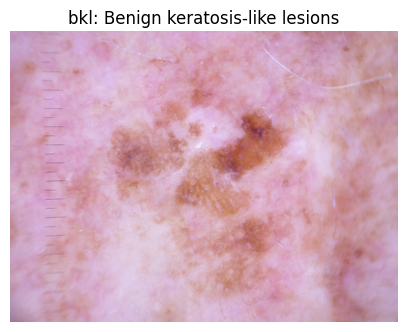

In [35]:
from PIL import Image
import matplotlib.pyplot as plt
example_row = df.iloc[0]
example_image = Image.open(example_row["image_path"])
plt.figure(figsize=(5, 5))
plt.imshow(example_image)
plt.title(
    example_row["dx"]
    + ": "
    + lesion_names[example_row["dx"]]
)
plt.axis("off")
plt.show()

In [39]:
class_names=sorted(df["dx"].unique())
class_to_number={
class_name:number
for number, class_name in enumerate(class_names)
}
number_to_class={
number:class_name
for class_name, number in class_to_number.items()
}
df["label"]=df["dx"].map(class_to_number)
print("Class names:", class_names)
print("Class mapping:", class_to_number)
print(df[["image_id", "dx", "label"]].head())

Class names: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
       image_id   dx  label
0  ISIC_0027419  bkl      2
1  ISIC_0025030  bkl      2
2  ISIC_0026769  bkl      2
3  ISIC_0025661  bkl      2
4  ISIC_0031633  bkl      2


In [46]:
from sklearn.model_selection import GroupShuffleSplit
first_split = GroupShuffleSplit(
n_splits=1,
train_size=0.70,
random_state=42
)
train_indices,temporary_indices=next(
first_split.split(
df,
groups=df["lesion_id"]
)
)
train_df = df.iloc[train_indices].reset_index(drop=True)
temporary_df = df.iloc[temporary_indices].reset_index(drop=True)
second_split = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=42
)
validation_indices, test_indices = next(
    second_split.split(
        temporary_df,
        groups=temporary_df["lesion_id"]
    )
)
validation_df = temporary_df.iloc[validation_indices].reset_index(drop=True)
test_df = temporary_df.iloc[test_indices].reset_index(drop=True)
print("Training images:", len(train_df))
print("Validation images:", len(validation_df))
print("Testing images:", len(test_df))

Training images: 7002
Validation images: 1519
Testing images: 1494


In [47]:
train_lesions = set(train_df["lesion_id"])
validation_lesions = set(validation_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])
print(
    "Train-validation overlap:",
    len(train_lesions.intersection(validation_lesions))
)
print(
    "Train-test overlap:",
    len(train_lesions.intersection(test_lesions))
)
print(
    "Validation-test overlap:",
    len(validation_lesions.intersection(test_lesions))
)

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0


In [48]:
import tensorflow as tf
import numpy as np
print("TensorFlow version:", tf.__version__)
print(
    "GPU available:",
    len(tf.config.list_physical_devices("GPU")) > 0
)

TensorFlow version: 2.20.0
GPU available: True


In [49]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUMBER_OF_CLASSES= len(class_names)
print("Number of classes:", NUMBER_OF_CLASSES)


Number of classes: 7


In [50]:

def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )
    image = tf.image.resize(
        image,
        [IMAGE_SIZE, IMAGE_SIZE]
    )
    image = tf.cast(
        image,
        tf.float32
    )
    return image, label

In [52]:
def create_dataset(dataframe, training=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label"].values
    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )
    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if training:

        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )
    return dataset

In [53]:
train_dataset = create_dataset(
    train_df,
    training=True
)
validation_dataset = create_dataset(
    validation_df
)
test_dataset = create_dataset(
    test_df
)
print(train_dataset)
print(validation_dataset)
print(test_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


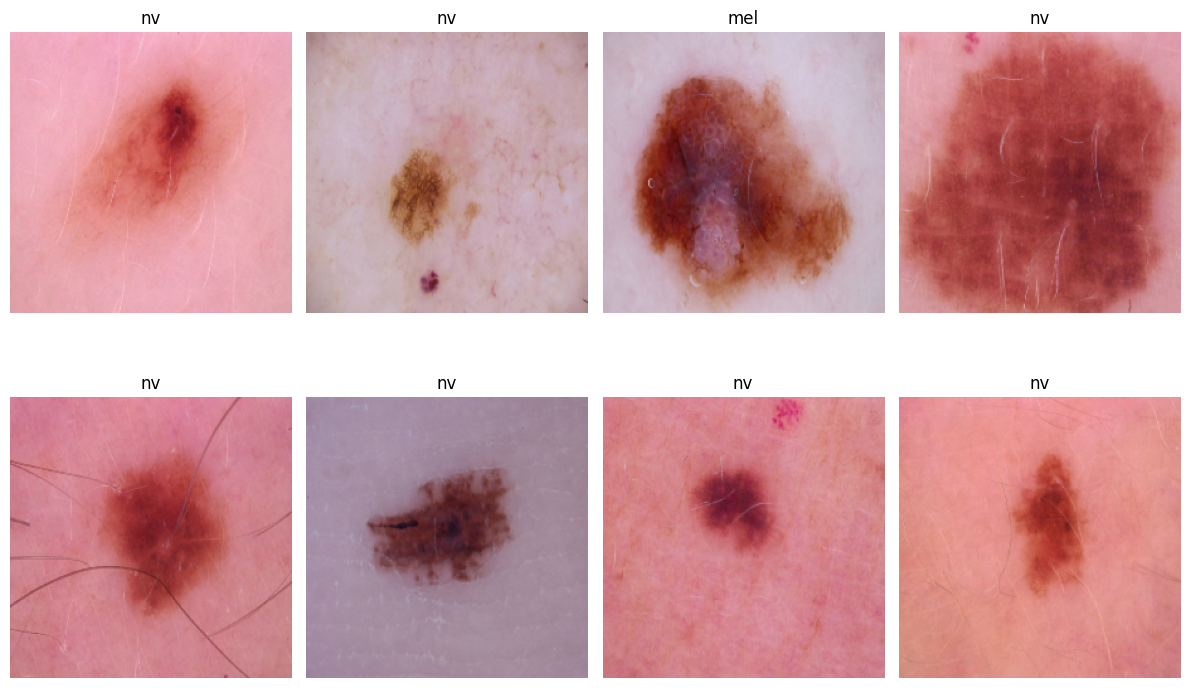

In [54]:
plt.figure(figsize=(12, 8))
for images, labels in train_dataset.take(1):
    number_to_show = min(
        8,
        len(images)
    )
    for index in range(number_to_show):
        plt.subplot(
            2,
            4,
            index + 1
        )
        plt.imshow(
            tf.cast(
                images[index],
                tf.uint8
            )
        )
        label_number = int(labels[index])
        class_code = number_to_class[label_number]
        plt.title(class_code)
        plt.axis("off")
plt.tight_layout()
plt.show()

In [55]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal_and_vertical"
    ),
    tf.keras.layers.RandomRotation(
        0.10
    ),
    tf.keras.layers.RandomZoom(
        0.10
    ),
    tf.keras.layers.RandomContrast(
        0.10
    )

])

In [58]:
from sklearn.utils.class_weight import compute_class_weight
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(
        NUMBER_OF_CLASSES
    ),
    y=train_df["label"].values
)
class_weights = {
    class_number: float(weight)
    for class_number, weight
    in enumerate(class_weight_values)
}
print(class_weights)

{0: 4.832298136645963, 1: 2.625421822272216, 2: 1.3499132446500868, 3: 11.23916532905297, 4: 1.2990723562152133, 5: 0.21201477623690426, 6: 10.419642857142858}


In [65]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    )
)
base_model.trainable = False
print("EfficientNetB0 loaded")

EfficientNetB0 loaded


In [ ]:
inputs = tf.keras.Input(
    shape=(
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    )
)
x = data_augmentation(inputs)
x = base_model(
    x,
    training=False
)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)
outputs = tf.keras.layers.Dense(
    NUMBER_OF_CLASSES,
    activation="softmax"
)(x)
model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)
model.summary()

In [ ]:
model.compile(
optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_ham10000_model.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.000001
    )
]

In [68]:
import tensorflow as tf
IMAGE_SIZE = 224
NUMBER_OF_CLASSES = 7
base_model = tf.keras. applications.EfficientNetB0(
include_top=False,
weights="imagenet",
input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)
base_model.trainable = False
data_augmentation = tf.keras.Sequential([
tf.keras.layers.RandomFlip("horizontal_and_vertical"),
tf.keras.layers.RandomRotation(0.10),
tf.keras.layers.RandomZoom(0.10),
tf.keras.layers.RandomContrast(0.10)
])
inputs = tf.keras.Input(
shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)
x = data_augmentation(inputs)
x = base_model(
x,
training=False
)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)
outputs = tf.keras.layers.Dense(
NUMBER_OF_CLASSES,
activation="softmax"
)(x)
model = tf.keras.Model(
inputs=inputs,
outputs=outputs
)
model.compile(
optimizer=tf.keras.optimizers.Adam(
learning_rate=0.001
),
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)
print("Model created successfully")

Model created successfully


In [73]:
callbacks= [
    tf.keras.callbacks.EarlyStopping(
  monitor="val_loss",
patience=3,
restore_best_weights=True
),
tf.keras.callbacks.ModelCheckpoint(
    "best_ham10000_model.keras",
    monitor="val_loss",
    save_best_only=True
),
tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.000001
)
]

In [74]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 103s 152ms/step - accuracy: 0.4235 - loss: 1.6230 - val_accuracy: 0.5003 - val_loss: 1.3588 - learning_rate: 0.0010
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 64s 117ms/step - accuracy: 0.5288 - loss: 1.3208 - val_accuracy: 0.5800 - val_loss: 1.1561 - learning_rate: 0.0010
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 57s 122ms/step - accuracy: 0.5533 - loss: 1.2109 - val_accuracy: 0.5912 - val_loss: 1.1504 - learning_rate: 0.0010
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 94s 124ms/step - accuracy: 0.5694 - loss: 1.1508 - val_accuracy: 0.6136 - val_loss: 1.0710 - learning_rate: 0.0010
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - accuracy: 0.5743 - loss: 1.1261 - val_accuracy: 0.6590 - val_loss: 0.9783 - learning_rate: 0.0010
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 70s 136ms/step - accuracy: 0.6024 - loss: 1.0572 - val_accuracy: 0.5629 - val_loss: 1.1880 - learning_rate: 0.0010
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 68s 132ms/step - accuracy: 0.

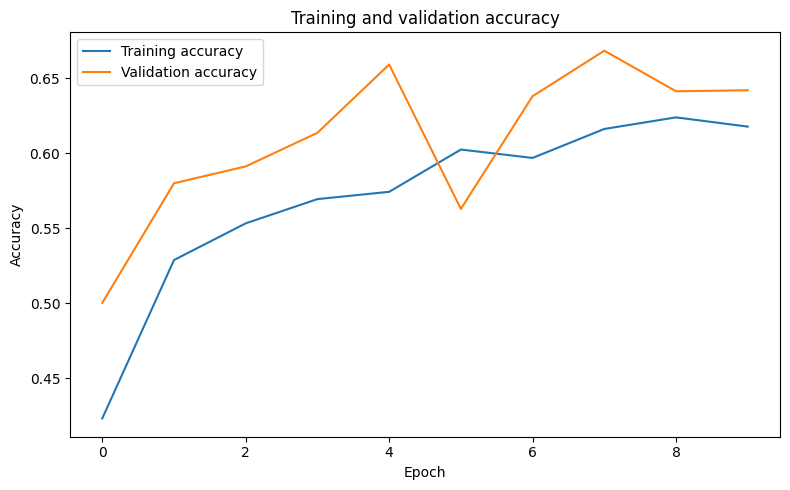

In [78]:
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["accuracy"],
    label="Training accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(
    "accuracy_graph.png",
    dpi=200
)
plt.show()

In [79]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
print(
    "Trainable EfficientNet layers:",
    sum(
        layer.trainable
        for layer in base_model.layers
    )
)

Trainable EfficientNet layers: 20


In [80]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001

    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [81]:
fine_tune_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 79s 144ms/step - accuracy: 0.3211 - loss: 1.3607 - val_accuracy: 0.4213 - val_loss: 1.5123 - learning_rate: 1.0000e-05
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 65s 139ms/step - accuracy: 0.3745 - loss: 1.2549 - val_accuracy: 0.4483 - val_loss: 1.4356 - learning_rate: 1.0000e-05
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 79s 191ms/step - accuracy: 0.4175 - loss: 1.2102 - val_accuracy: 0.4674 - val_loss: 1.3864 - learning_rate: 5.0000e-06


In [83]:
test_loss, test_accuracy = model.evaluate(
    test_dataset
)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.4170 - loss: 1.5246
Test loss: 1.5245637893676758
Test accuracy: 0.417001336812973


In [84]:
true_labels = []

predicted_labels = []

prediction_probabilities = []

for images, labels in test_dataset:

    probabilities = model.predict(

        images,

        verbose=0

    )

    predictions = np.argmax(

        probabilities,

        axis=1

    )

    true_labels.extend(

        labels.numpy()

    )

    predicted_labels.extend(

        predictions
    )

    prediction_probabilities.extend(
        probabilities
    )
true_labels = np.array(
    true_labels
)
predicted_labels = np.array(

    predicted_labels
)
prediction_probabilities = np.array(
    prediction_probabilities
)
print(
    "Number of predictions:",
    len(predicted_labels)
)

Number of predictions: 1494


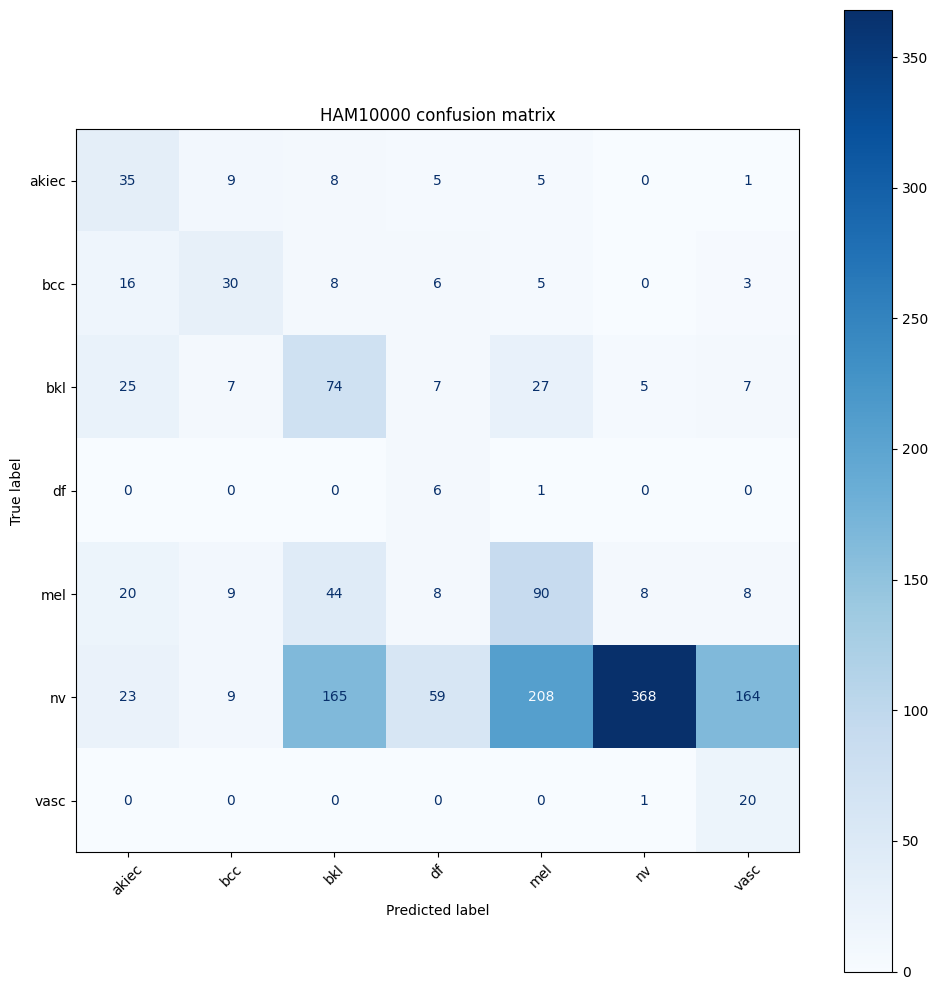

In [85]:
from sklearn.metrics import confusion_matrix

from sklearn.metrics import ConfusionMatrixDisplay

matrix = confusion_matrix(

    true_labels,

    predicted_labels,

    labels=np.arange(
        NUMBER_OF_CLASSES
    )

)

figure, axis = plt.subplots(

    figsize=(10, 10)

)

matrix_display = ConfusionMatrixDisplay(

    confusion_matrix=matrix,

    display_labels=class_names

)

matrix_display.plot(

    ax=axis,

    cmap="Blues",

    values_format="d"

)

plt.title("HAM10000 confusion matrix")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(

    "confusion_matrix.png",

    dpi=200

)

plt.show()

In [86]:
from sklearn.metrics import accuracy_score

from sklearn.metrics import balanced_accuracy_score

from sklearn.metrics import f1_score

from sklearn.metrics import recall_score

accuracy = accuracy_score(

    true_labels,

    predicted_labels

)

balanced_accuracy = balanced_accuracy_score(

    true_labels,

    predicted_labels

)

macro_f1 = f1_score(

    true_labels,

    predicted_labels,

    average="macro",

    zero_division=0

)

macro_recall = recall_score(

    true_labels,

    predicted_labels,

    average="macro",

    zero_division=0

)

print("Accuracy:", accuracy)

print("Balanced accuracy:", balanced_accuracy)

print("Macro F1:", macro_f1)

print("Macro recall:", macro_recall)

Accuracy: 0.4170013386880857
Balanced accuracy: 0.5919798964338912
Macro F1: 0.33523093637529877
Macro recall: 0.5919798964338912


In [87]:
results_df = test_df.copy()

results_df["predicted_label"] = predicted_labels

results_df["predicted_code"] = results_df["predicted_label"].map(

    number_to_class

)

results_df["confidence"] = np.max(

    prediction_probabilities,

    axis=1

)

mistakes_df = results_df[

    results_df["label"]

    != results_df["predicted_label"]

].copy()

mistakes_df = mistakes_df.sort_values(

    "confidence",

    ascending=False

)

print("Number of mistakes:", len(mistakes_df))

print(

    mistakes_df[

        [

            "image_id",

            "dx",

            "predicted_code",

            "confidence"

        ]

    ].head(10)

)


Number of mistakes: 871
          image_id   dx predicted_code  confidence
1251  ISIC_0024793   nv           vasc    0.984027
583   ISIC_0030141   nv           vasc    0.982982
1250  ISIC_0031340   nv           vasc    0.976298
1493  ISIC_0032258  mel           vasc    0.969290
92    ISIC_0024982  bkl           vasc    0.968614
1249  ISIC_0027122   nv           vasc    0.966965
1040  ISIC_0027024   nv            mel    0.935546
1232  ISIC_0031447   nv           vasc    0.930985
644   ISIC_0030975   nv           vasc    0.920437
709   ISIC_0031419   nv           vasc    0.916339


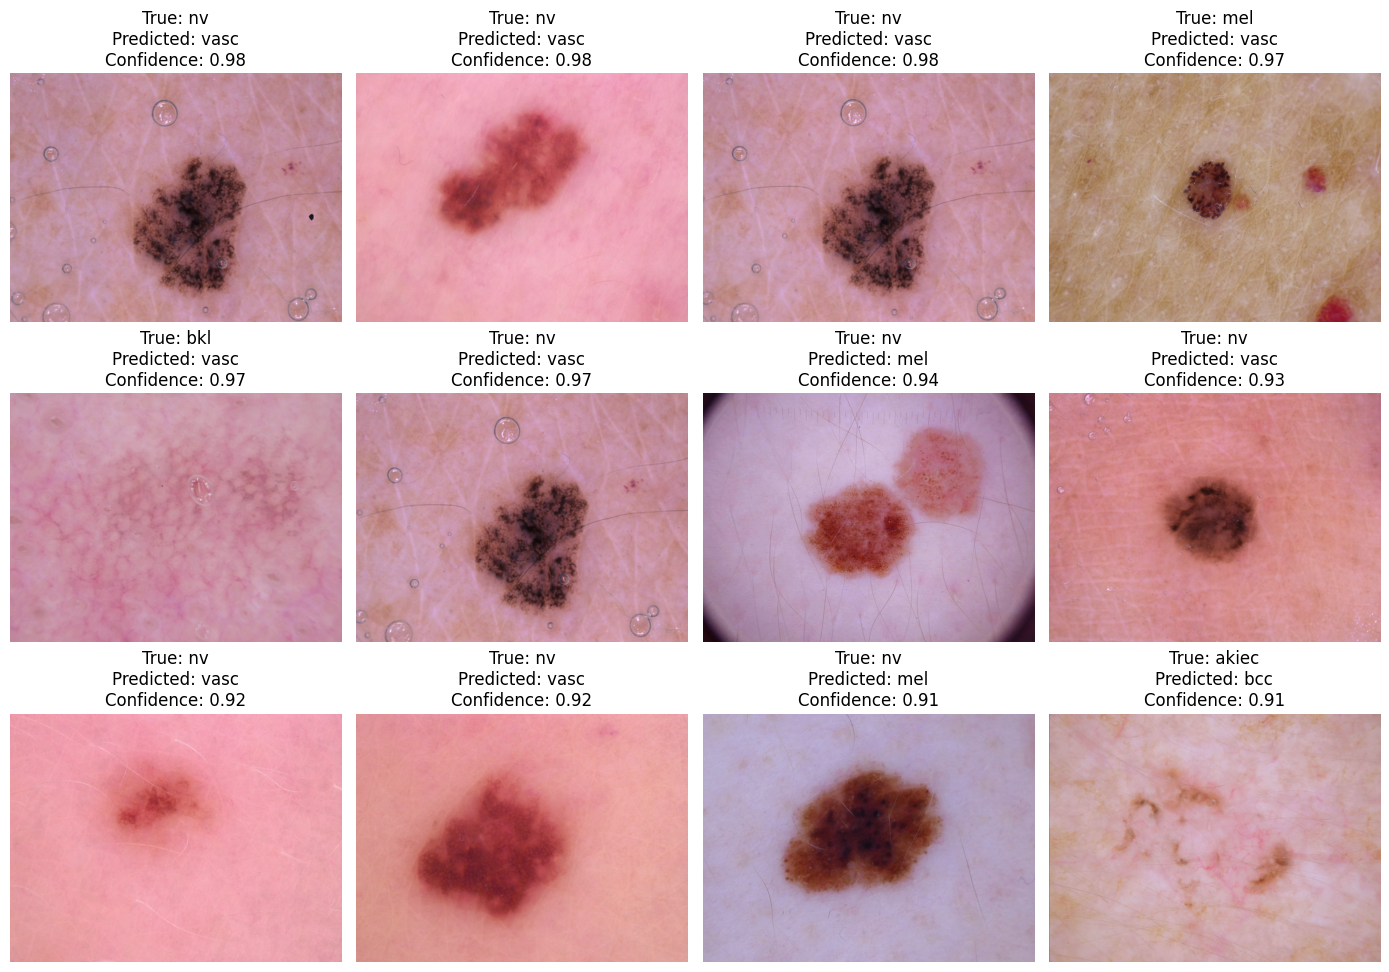

In [88]:
plt.figure(figsize=(14, 10))

number_to_display = min(

    12,

    len(mistakes_df)

)

for index in range(number_to_display):

    row = mistakes_df.iloc[index]

    image = Image.open(

        row["image_path"]

    )

    plt.subplot(

        3,

        4,

        index + 1

    )

    plt.imshow(image)

    plt.title(

        f"True: {row['dx']}\n"

        f"Predicted: {row['predicted_code']}\n"

        f"Confidence: {row['confidence']:.2f}"

    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(

    "high_confidence_mistakes.png",

    dpi=200

)

plt.show()

In [94]:
model.save(
"HAM10000_EfficientNetB0_Final.keras"
)
print("Model saved")

Model saved


In [92]:
results_df = test_df.copy()

results_df["predicted_label"] = predicted_labels

results_df["predicted_code"] = results_df["predicted_label"].map(number_to_class)

results_df["confidence"] = np.max(
prediction_probabilities,
axis=1
)

mistakes_df = results_df[
results_df["label"] != results_df["predicted_label"]
].copy()

mistakes_df = mistakes_df.sort_values(
"confidence",
ascending=False
)

In [90]:
results_df.to_csv(
    "HAM10000_test_predictions.csv",
    index=False
)
mistakes_df.to_csv(
    "HAM10000_mistakes.csv",
    index=False
)
print("Prediction files saved")

Prediction files saved


In [91]:
import json

results_summary = {

    "dataset": "HAM10000",

    "model": "EfficientNetB0",

    "number_of_classes": int(

        NUMBER_OF_CLASSES

    ),

    "training_images": int(

        len(train_df)

    ),

    "validation_images": int(

        len(validation_df)

    ),

    "testing_images": int(

        len(test_df)

    ),

    "accuracy": float(

        accuracy

    ),

    "balanced_accuracy": float(

        balanced_accuracy

    ),

    "macro_f1": float(

        macro_f1

    ),

    "macro_recall": float(

        macro_recall

    ),
    "disclaimer": (
        "Educational machine-learning research only. "
        "Not a medical diagnostic system."
    )
}
with open(
    "HAM10000_results.json",
    "w"
) as file:
    json.dump(
        results_summary,
        file,
        indent=4
    )
print(results_summary)

{'dataset': 'HAM10000', 'model': 'EfficientNetB0', 'number_of_classes': 7, 'training_images': 7002, 'validation_images': 1519, 'testing_images': 1494, 'accuracy': 0.4170013386880857, 'balanced_accuracy': 0.5919798964338912, 'macro_f1': 0.33523093637529877, 'macro_recall': 0.5919798964338912, 'disclaimer': 'Educational machine-learning research only. Not a medical diagnostic system.'}
